In [ ]:
#### Topics COvered ####
# What is MRO?
# What is name mangling ?

In [ ]:
###### Encapsulation  ( Public , Protected, Private ) ############
# public    :: {"syntax": "name", "Access": "anywhere" }
# Protected :: {"syntax": "_name", "Access": "class + Child Classes" }
# Private   :: {"syntax": "__name", "Access": "only inside class"}

## Inheritance ( Single, Multilevel , Multiple )
## Method Overriding ( Same Method name )
## Method Overloading ---> Not supported 
## Abstraction(Contract)

In [ ]:
## Class with getter / Setter 

In [18]:
class A:
    def __init__(self):
        print("Class A")
    
    def a(self):
        print("a")

class B(A):
    def __init__(self):
        super().__init__()
        print("Class B")
    
    def b(self):
        print("b")


class C(A):
    def __init__(self):
        print("Class C")
    
    def c(self):
        print("c")

class D(B,C): # not available in java # ambiguity 
    def __init__(self):
        super().__init__()
        print("Class D")
    
    def d(self):
        print("d")

dobj = D()
print(D.__mro__)


Class C
Class B
Class D
(<class '__main__.D'>, <class '__main__.B'>, <class '__main__.C'>, <class '__main__.A'>, <class 'object'>)


## Python MRO (Method Resolution Order) Explained

Let me visualize the inheritance structure first:Now let me explain what's happening step by step.

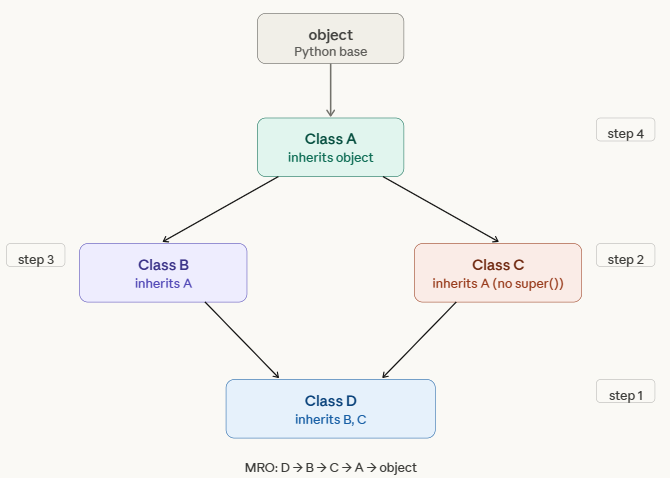

In [ ]:
# (<class '__main__.D'>, <class '__main__.B'>, <class '__main__.C'>, <class '__main__.A'>, <class 'object'>)


## Why you got `Class C → Class B → Class D` instead of `A → B → C → D`

Your expectation was based on intuition — "B calls super, so A should print first, then B, then C, then D." The key to understanding the real output is **Python's MRO (C3 Linearization algorithm)** and **what `super()` actually means in MRO context**.

## What MRO says

`D.__mro__` gives: `D → B → C → A → object`

This is the **lookup chain** Python builds using the C3 algorithm. The rule is: children always come before parents, and the order of `class D(B, C)` is preserved (B before C).

## Tracing the `__init__` calls

When you call `D()`, Python calls `D.__init__`, which calls `super().__init__()`. Here's the crucial part — **`super()` doesn't mean "my parent". It means "the next class in the MRO".**

| Step | Who runs | What happens |
|------|----------|--------------|
| 1 | `D.__init__` | calls `super().__init__()` → next in MRO is **B** |
| 2 | `B.__init__` | calls `super().__init__()` → next in MRO after B is **C** |
| 3 | `C.__init__` | **does NOT call `super()`** → prints `"Class C"` and stops |
| 4 | Back to `B.__init__` | prints `"Class B"` |
| 5 | Back to `D.__init__` | prints `"Class D"` |

So the output is:
```
Class C    ← C finishes first (deepest call)
Class B    ← B finishes after C returns
Class D    ← D finishes last
```

Notice `"Class A"` never prints — because `C.__init__` doesn't call `super()`, so A's `__init__` is **never reached**.

## The two key insights

**1. `super()` follows MRO, not the class tree.** When `B` calls `super().__init__()`, it doesn't call `A.__init__()`. It calls whoever is next in the MRO — which is `C`.

**2. `C` breaks the chain.** Because `C.__init__` doesn't call `super()`, the cooperative inheritance chain stops there. `A.__init__` is skipped entirely.


## How to get your expected output `A → B → C → D`

Make `C` call `super()` too:

```python
class C(A):
    def __init__(self):
        super().__init__()   # ← add this
        print("Class C")
```

Now the chain completes: `D` → `B` → `C` → `A` → prints in reverse order as the stack unwinds:
```
Class A
Class C
Class B
Class D
```

This pattern — every class calling `super().__init__()` — is called **cooperative multiple inheritance**, and it's the correct way to use `super()` in a diamond inheritance hierarchy.